In [1]:
%pip install pandas numpy scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import pickle

In [3]:
df = pd.read_csv("../dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
df.drop("customerID", axis=1, inplace=True)

In [8]:
print(df["TotalCharges"].dtype)

str


In [9]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [10]:
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [11]:
df.dropna(inplace=True)

In [12]:
df["Churn"]= df["Churn"].map({"Yes": 1, "No": 0})

In [13]:
df = pd.get_dummies(df, drop_first=True)

In [14]:
print(df['Churn'].value_counts(normalize=True))


Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64


In [15]:
df['AvgCharges'] = df['TotalCharges'] / (df['tenure'] + 1)

df['tenure_group'] = pd.cut(df['tenure'],
                           bins=[0,12,24,48,72],
                           labels=['0-1yr','1-2yr','2-4yr','4-6yr'])

In [16]:
df['HighValue'] = (df['MonthlyCharges'] > df['MonthlyCharges'].median()).astype(int)

df['LongTerm'] = (df['tenure'] > 24).astype(int)

In [17]:
df = pd.get_dummies(df, drop_first=True)


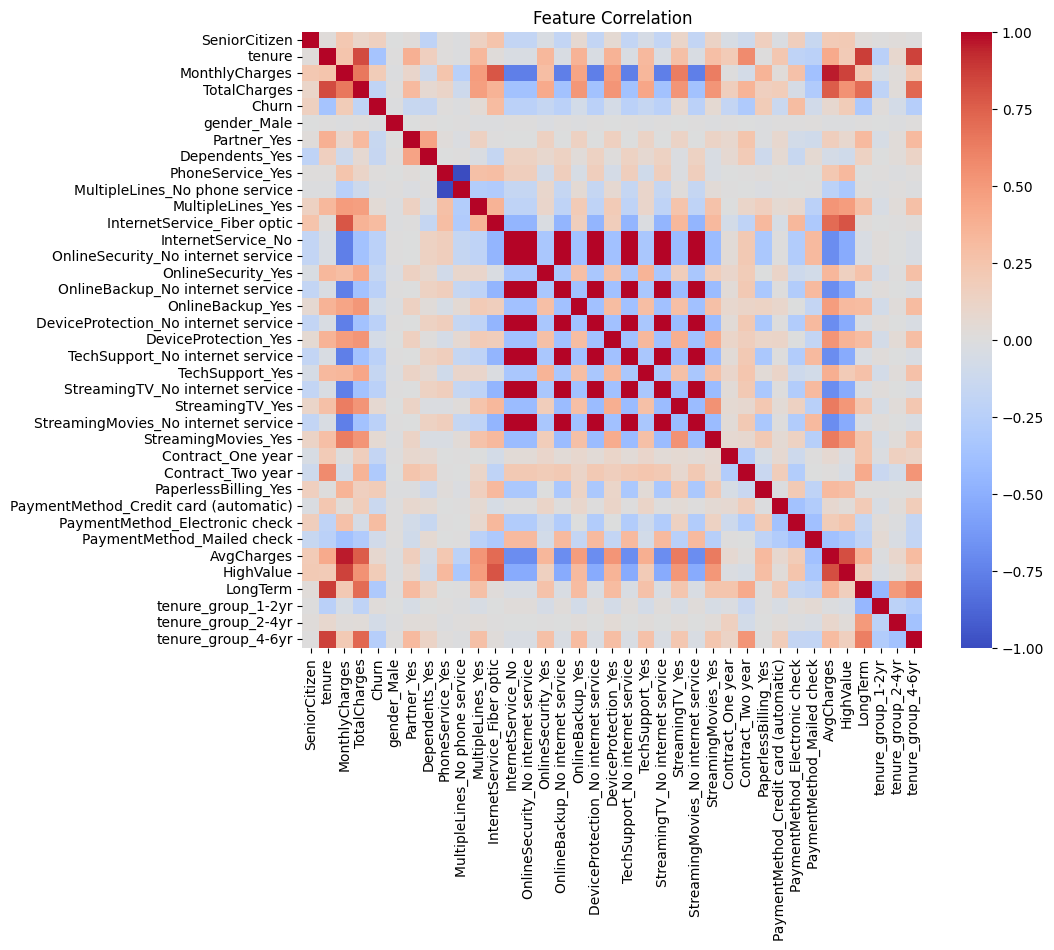

In [18]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

In [19]:
def get_risk(prob):
    if prob > 0.7:
        return "High Risk"
    elif prob > 0.4:
        return "Medium Risk"
    else:
        return "Low Risk"

In [21]:
df.head()


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,AvgCharges,HighValue,LongTerm,tenure_group_1-2yr,tenure_group_2-4yr,tenure_group_4-6yr
0,0,1,29.85,29.85,0,False,True,False,False,True,...,True,False,True,False,14.925000,0,0,False,False,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,True,53.985714,0,1,False,True,False
2,0,2,53.85,108.15,1,True,False,False,True,False,...,True,False,False,True,36.050000,0,0,False,False,False
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,40.016304,0,1,False,True,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,True,False,True,False,50.550000,1,0,False,False,False


In [23]:
df_copy1 = df.copy()
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [28]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [29]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

rf_pipeline = Pipeline([
    ('model', RandomForestClassifier(n_estimators=150, max_depth=10))
])

gb_pipeline = Pipeline([
    ('model', GradientBoostingClassifier())
])

In [30]:
lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)
gb_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum

In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve

def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print(f"\n{name} Results:")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))

    return y_pred, y_prob

In [32]:
lr_pred, lr_prob = evaluate_model(lr_pipeline, X_test, y_test, "Logistic Regression")
rf_pred, rf_prob = evaluate_model(rf_pipeline, X_test, y_test, "Random Forest")
gb_pred, gb_prob = evaluate_model(gb_pipeline, X_test, y_test, "Gradient Boosting")


Logistic Regression Results:
Accuracy: 0.7960199004975125
Precision: 0.6389776357827476
Recall: 0.5347593582887701
F1 Score: 0.5822416302765647
ROC-AUC: 0.8375545501136298

Random Forest Results:
Accuracy: 0.7903340440653873
Precision: 0.6366782006920415
Recall: 0.4919786096256685
F1 Score: 0.555052790346908
ROC-AUC: 0.8337328066842331

Gradient Boosting Results:
Accuracy: 0.7981520966595593
Precision: 0.6461038961038961
Recall: 0.5320855614973262
F1 Score: 0.5835777126099707
ROC-AUC: 0.8417399609672259


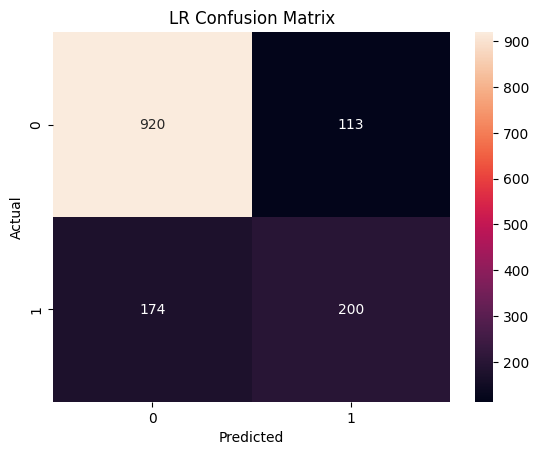

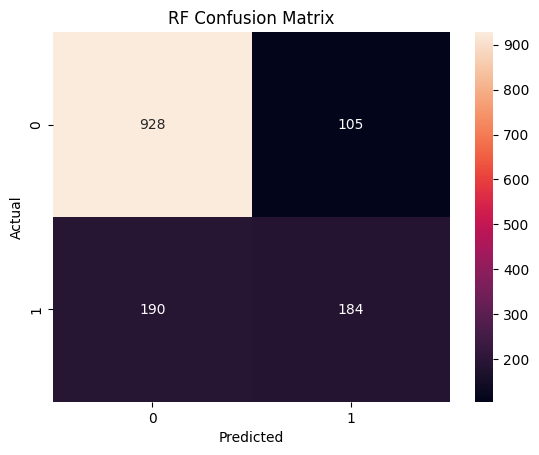

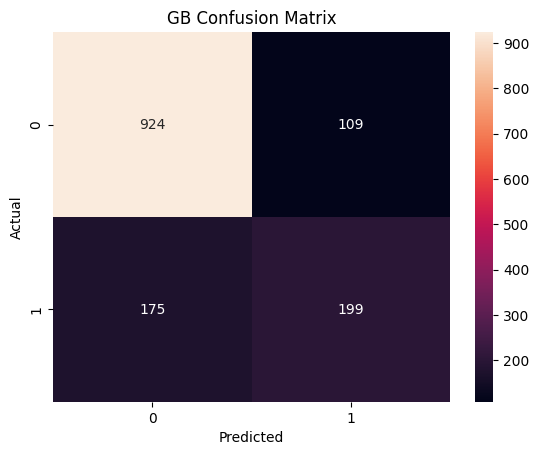

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion(y_test, y_pred, title):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_confusion(y_test, lr_pred, "LR Confusion Matrix")
plot_confusion(y_test, rf_pred, "RF Confusion Matrix")
plot_confusion(y_test, gb_pred, "GB Confusion Matrix")

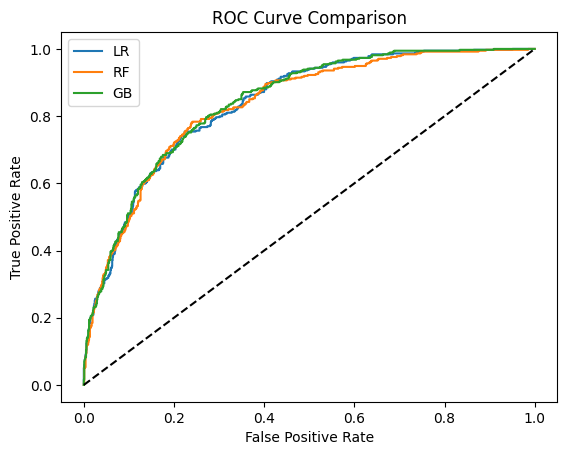

In [34]:
plt.figure()

for prob, name in [(lr_prob, "LR"), (rf_prob, "RF"), (gb_prob, "GB")]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [35]:
def get_score(y_test, prob):
    return roc_auc_score(y_test, prob)

print("LR ROC:", get_score(y_test, lr_prob))
print("RF ROC:", get_score(y_test, rf_prob))
print("GB ROC:", get_score(y_test, gb_prob))

LR ROC: 0.8375545501136298
RF ROC: 0.8337328066842331
GB ROC: 0.8417399609672259


In [36]:
scores = {
    "LR": roc_auc_score(y_test, lr_prob),
    "RF": roc_auc_score(y_test, rf_prob),
    "GB": roc_auc_score(y_test, gb_prob)
}

best_name = max(scores, key=scores.get)

if best_name == "LR":
    best_model = lr_pipeline
elif best_name == "RF":
    best_model = rf_pipeline
else:
    best_model = gb_pipeline

print("Best Model:", best_name)

Best Model: GB


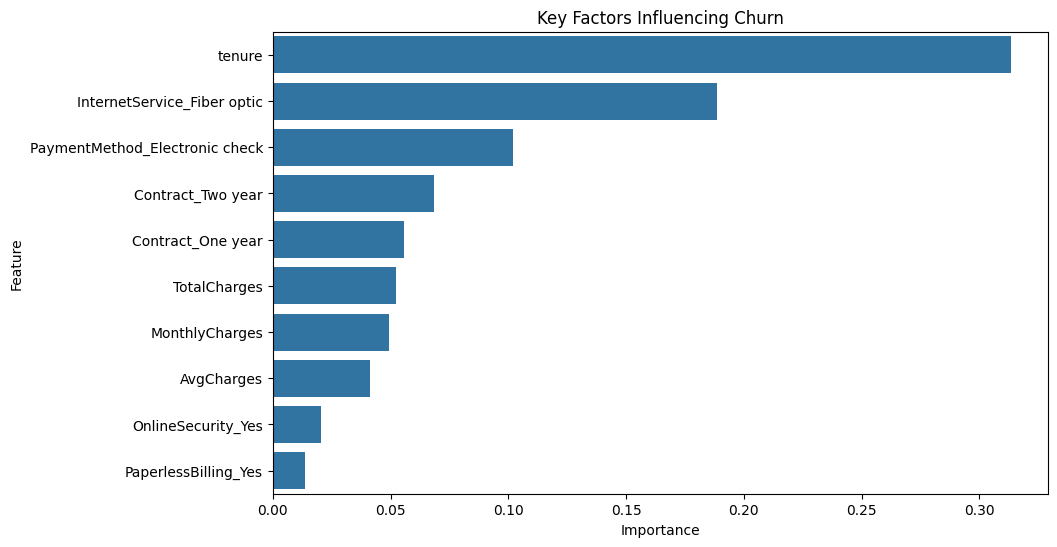

In [38]:
if best_name in ["RF", "GB"]:
    model = best_model.named_steps['model']
    importances = model.feature_importances_

    feat_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(10,6))
    sns.barplot(x='Importance', y='Feature', data=feat_df.head(10))
    plt.title("Key Factors Influencing Churn")
    plt.show()

In [39]:
import pickle

pickle.dump(best_model, open("../model/model.pkl", "wb"))
pickle.dump(X.columns.tolist(), open("../model/columns.pkl", "wb"))

In [40]:
model = pickle.load(open("../model/model.pkl", "rb"))

sample = X_test.iloc[0:1]
print("Prediction:", model.predict(sample))
print("Probability:", model.predict_proba(sample))

Prediction: [0]
Probability: [[0.97774029 0.02225971]]


In [41]:
prediction = model.predict(sample)[0]
prob = model.predict_proba(sample)[0][1]

churn = "Yes" if prediction == 1 else "No"

def get_risk(prob):
    if prob > 0.7:
        return "High Risk"
    elif prob > 0.4:
        return "Medium Risk"
    else:
        return "Low Risk"

risk = get_risk(prob)

print("Churn:", churn)
print("Probability:", prob)
print("Risk:", risk)

Churn: No
Probability: 0.022259714764874847
Risk: Low Risk
